In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
HwannierUp, cell_mapUp = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt");
HwannierDn, cell_mapDn = hwannier("wannierDn"), np.loadtxt("wannierDn.map.txt");

In [4]:
EsUp, _ = wannier_bands(HwannierUp, cell_mapUp, hcat(bandstructkpoints2q(kpointsfile="../bandstruct.kpoints")...));
EsDn, _ = wannier_bands(HwannierDn, cell_mapDn, hcat(bandstructkpoints2q(kpointsfile="../bandstruct.kpoints")...));

In [7]:
np.savetxt("EsUp.txt", EsUp)
np.savetxt("EsDn.txt", EsDn)

In [8]:
EnergiesUp, DOSUp = density_of_states(HwannierUp, cell_mapUp, Val(2), histogram_width=1000, mesh=20, monte_carlo=true, num_blocks=100)
EnergiesDn, DOSDn = density_of_states(HwannierDn, cell_mapDn, Val(2), histogram_width=1000, mesh=20, monte_carlo=true, num_blocks=100)

([-25.607765363427262, -25.606765350922227, -25.60576533841719, -25.604765325912155, -25.60376531340712, -25.60276530090208, -25.601765288397047, -25.600765275892012, -25.599765263386978, -25.59876525088194  …  5.190619766663804, 5.1916197791688425, 5.192619791673877, 5.193619804178912, 5.19461981668395, 5.195619829188985, 5.1966198416940195, 5.197619854199054, 5.198619866704092, 5.199619879209127], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [9]:
np.savetxt("DosUp.txt", hcat(EnergiesUp, DOSUp))
np.savetxt("DosDn.txt", hcat(EnergiesDn, DOSDn))

In [10]:
epsilons = zeros(100, 100);
kpoints = bandstructkpoints2q(interpolate=5);
lattice_vectors = loadlattice("./wannier.out")
energies = collect(range(0, 100, length=100*1000));
landau_lower = zeros(80);
landau_upper = zeros(80);

In [11]:
for (i, k) in enumerate(kpoints[1:100])
    i == 1 && continue
    polarizations = parse.(Float64, readlines("Plasmon.out-$i"))
    for (j, ω) in enumerate(range(0.05, 0.5, length=100))
        epsilons[i, j] = imag(1 / ϵ(k, lattice_vectors, ω, energies, polarizations, δ=0.001))
    end
end

In [12]:
plasmon = [range(0.05, 0.5, length=100)[argmax(x)] for x in eachrow(log.(abs.(epsilons[2:80, :])))];
plasmon = [0, plasmon...]
qs, confinements = confinement(lattice_vectors, kpoints[1:80], plasmon)
confinements[1] = 0;
plasmon = smooth(plasmon, win_len=20)
confinements = smooth(confinements, win_len=10);

In [13]:
for (i, k) in enumerate(kpoints[1:80])
    polarizations = parse.(Float64, readlines("Plasmon.out-$i"))
    non_zero_impols = energies[findall(.!iszero.(polarizations))]
    landau_lower[i] = maximum([filter(x-> x < plasmon[i], non_zero_impols)..., 0])
    landau_upper[i] = minimum(filter(x-> x > plasmon[i], non_zero_impols))
end

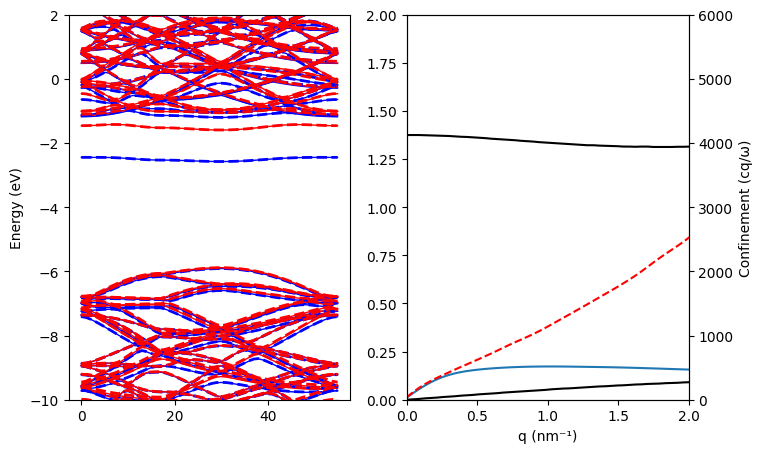

PyObject Text(0.5, 0, 'q (nm⁻¹)')

In [17]:
figure(figsize=(8, 5))

subplot(1, 2, 1)
plot_bands("../BN44BC.bands.eigenvals", kpointsfile = "../bandstruct.kpoints", spin=2, linewidth=1, to_greek=true)
plot_bands(HwannierUp, cell_mapUp, kpointsfile="../bandstruct.kpoints", linewidth=2, color="blue", linestyle="dashed")
plot_bands(HwannierDn, cell_mapDn, kpointsfile="../bandstruct.kpoints", linewidth=2, color="red", linestyle="dashed")
xlabel("")
ylim(-10, 2)

subplot(1, 2, 2)
plot(qs*10, plasmon)
plot(qs*10, landau_lower, color="black")
plot(qs*10, landau_upper, color="black")

xlabel("q (nm⁻¹)")
ylim(0, 2)
twinx()
plot(qs*10, confinements, color="red", linestyle="dashed")
ylim(0, 6000)
xlabel("q (nm⁻¹)")
xlim(0, maximum(qs)*10)
ylabel("Confinement (cq/ω)")
xlim(0, 2)
xlabel("q (nm⁻¹)")
#savefig("BN44NC-Plasmon.pdf")

In [14]:
np.savetxt("Plasmon.txt", hcat(qs, plasmon, confinements))

In [18]:
np.savetxt("Landau.txt", hcat(qs, landau_lower, landau_upper))